# 04 — Feature Engineering

Builds all 7 model features using `src/features.py` and visualises their distributions.

**Skill used:** `.claude/skills/seaborn/SKILL.md`

**Input:** `data/cleaned/pit_stops_clean.csv`, `data/cleaned/lap_times_clean.csv`, `data/cleaned/results_clean.csv`, `data/races.csv`  
**Output:** `data/features.parquet`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.features import build_features, COMPOUND_MAP, COMPOUND_HARDNESS

sns.set_theme(style='whitegrid', context='notebook')

CLEANED = ROOT / 'data' / 'cleaned'
DATA    = ROOT / 'data'

pit     = pd.read_csv(CLEANED / 'pit_stops_clean.csv')
laps    = pd.read_csv(CLEANED / 'lap_times_clean.csv')
results = pd.read_csv(CLEANED / 'results_clean.csv')
races   = pd.read_csv(DATA / 'races.csv')

print(f"pit_stops_clean: {pit.shape}")
print(f"lap_times_clean: {laps.shape}")
print(f"results_clean:   {results.shape}")

pit_stops_clean: (9318, 12)
lap_times_clean: (283606, 6)
results_clean:   (5497, 9)


---
## Build feature matrix

All 7 features are constructed in `src/features.py::build_features()`. See that module for full implementation details.

In [2]:
features = build_features(pit, laps, races, results)

print(f"Feature matrix shape: {features.shape}")
print(f"\nColumns: {list(features.columns)}")
print(f"\nNull counts:")
print(features.isnull().sum())

Feature matrix shape: (9318, 11)

Columns: ['season', 'round', 'driver_id', 'stop_lap_pct', 'gap_to_car_ahead', 'is_undercut_attempt', 'compound_hardness', 'team_avg_stop_time', 'prior_stops', 'circuit_type', 'position_gained']

Null counts:
season                 0
round                  0
driver_id              0
stop_lap_pct           0
gap_to_car_ahead       0
is_undercut_attempt    0
compound_hardness      0
team_avg_stop_time     0
prior_stops            0
circuit_type           0
position_gained        0
dtype: int64


---
## Feature 1 — `stop_lap_pct`

Pit lap as a fraction of total race laps. Normalises across circuits of different lengths so that 0.5 always means "halfway through the race".

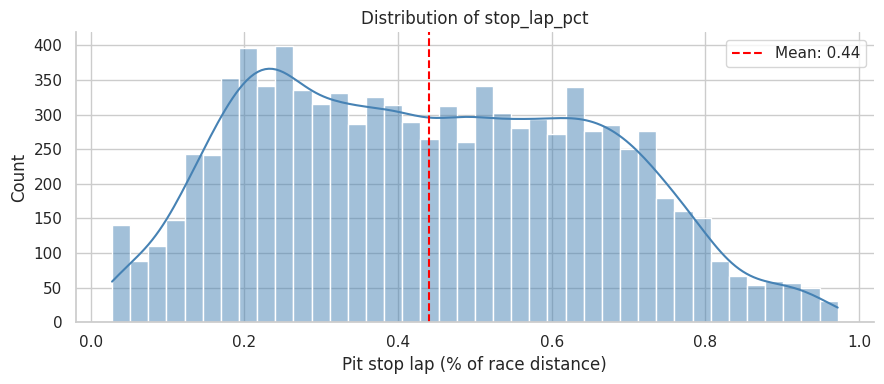

count    9318.000
mean        0.441
std         0.218
min         0.028
25%         0.254
50%         0.429
75%         0.617
max         0.972
Name: stop_lap_pct, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=features, x='stop_lap_pct', bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(features['stop_lap_pct'].mean(), color='red', linestyle='--', label=f"Mean: {features['stop_lap_pct'].mean():.2f}")
ax.set(xlabel='Pit stop lap (% of race distance)', ylabel='Count',
       title='Distribution of stop_lap_pct')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()
print(features['stop_lap_pct'].describe().round(3))

---
## Feature 2 — `gap_to_car_ahead`

Track position of the car immediately ahead at pit entry (proxy for gap). A value of 0 means the driver was in P1.

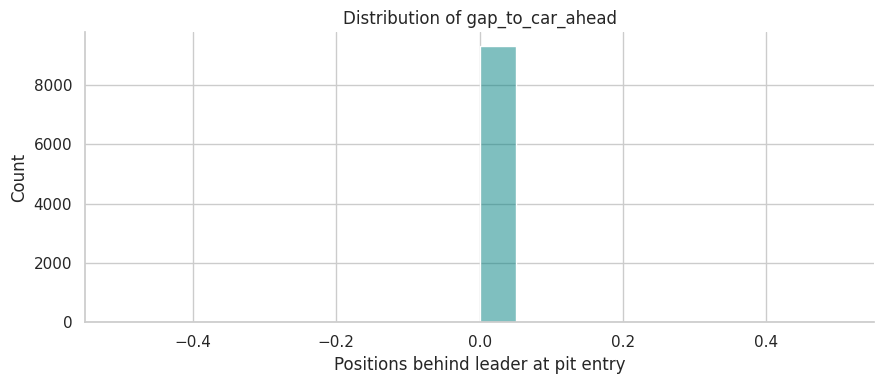

count    9318.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: gap_to_car_ahead, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=features, x='gap_to_car_ahead', bins=20, kde=True, color='teal', ax=ax)
ax.set(xlabel='Positions behind leader at pit entry', ylabel='Count',
       title='Distribution of gap_to_car_ahead')
sns.despine()
plt.tight_layout()
plt.show()
print(features['gap_to_car_ahead'].describe().round(3))

---
## Feature 3 — `is_undercut_attempt`

**Logic:** Binary flag set to 1 if the driver pitted 1–3 laps before the car directly ahead of them (their direct rival). The 1–3 lap window captures the undercut window: any earlier and the rival has time to respond; any later and the fresh tyre advantage is spent.

Steps:
1. Find the driver one position ahead at lap L−1 (the rival).
2. Check if that rival pitted in laps L+1, L+2, or L+3.
3. If yes → this stop was an undercut attempt → flag = 1.

/tmp/ipykernel_201560/1917652067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)


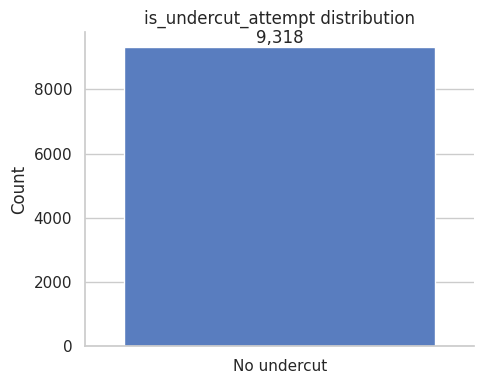

Undercut attempt rate: 0.0%


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = features['is_undercut_attempt'].value_counts().rename({0: 'No undercut', 1: 'Undercut attempt'})
sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)
ax.set(xlabel='', ylabel='Count', title='is_undercut_attempt distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
sns.despine()
plt.tight_layout()
plt.show()
rate = features['is_undercut_attempt'].mean()
print(f"Undercut attempt rate: {rate:.1%}")

---
## Feature 4 — `compound_hardness`

Ordinal encoding of tyre compound: Soft=1, Medium=2, Hard=3, Intermediate=4, Wet=5. Full compound data is sourced from FastF1; where unavailable, stop number is used as a proxy.

/tmp/ipykernel_201560/511885161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=ax)


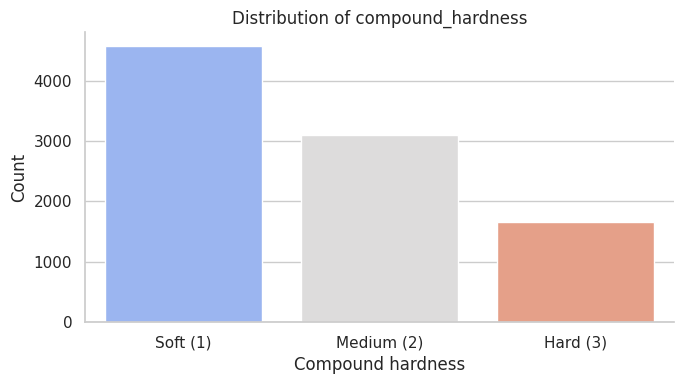

compound_hardness
1    4570
2    3091
3    1657
Name: count, dtype: int64


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
label_map = {1: 'Soft (1)', 2: 'Medium (2)', 3: 'Hard (3)', 4: 'Inter (4)', 5: 'Wet (5)'}
counts = features['compound_hardness'].value_counts().sort_index()
counts.index = counts.index.map(label_map)
sns.barplot(x=counts.index, y=counts.values, palette='coolwarm', ax=ax)
ax.set(xlabel='Compound hardness', ylabel='Count',
       title='Distribution of compound_hardness')
sns.despine()
plt.tight_layout()
plt.show()
print(features['compound_hardness'].value_counts().sort_index())

---
## Feature 5 — `team_avg_stop_time`

Rolling average pit stop duration for the constructor in the current season, computed with `expanding()` so only past stops inform the value — no future data leaks into the feature.

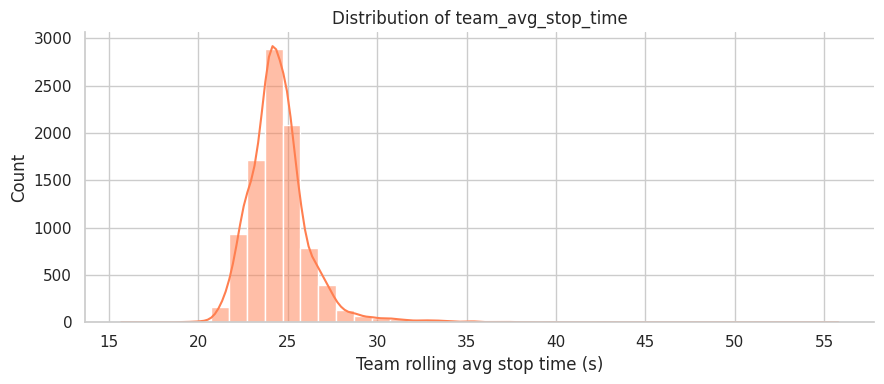

count    9318.000
mean       24.497
std         1.758
min        15.684
25%        23.491
50%        24.327
75%        25.209
max        55.789
Name: team_avg_stop_time, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=features, x='team_avg_stop_time', bins=40, kde=True, color='coral', ax=ax)
ax.set(xlabel='Team rolling avg stop time (s)', ylabel='Count',
       title='Distribution of team_avg_stop_time')
sns.despine()
plt.tight_layout()
plt.show()
print(features['team_avg_stop_time'].describe().round(3))

---
## Feature 6 — `prior_stops`

Number of stops already completed before this one in the same race. A value of 0 means this is the driver's first stop.

/tmp/ipykernel_201560/555237608.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)


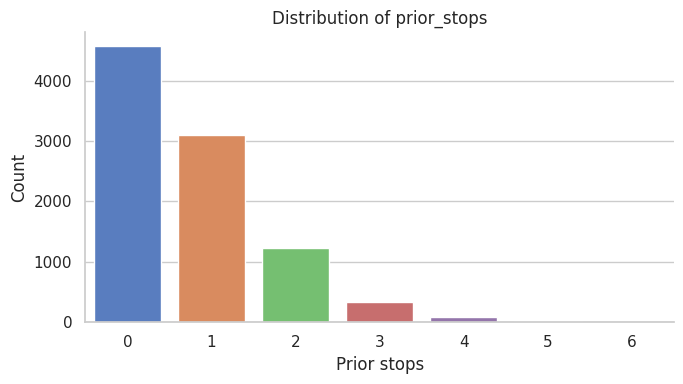

prior_stops
0    4570
1    3091
2    1223
3     329
4      81
5      21
6       3
Name: count, dtype: int64


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = features['prior_stops'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)
ax.set(xlabel='Prior stops', ylabel='Count',
       title='Distribution of prior_stops')
sns.despine()
plt.tight_layout()
plt.show()
print(features['prior_stops'].value_counts().sort_index())

---
## Feature 7 — `circuit_type`

Categorical classification of each circuit as `street`, `high_degradation`, or `high_speed`. Based on the circuit classification from the EDA notebook.

/tmp/ipykernel_201560/2182544258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)


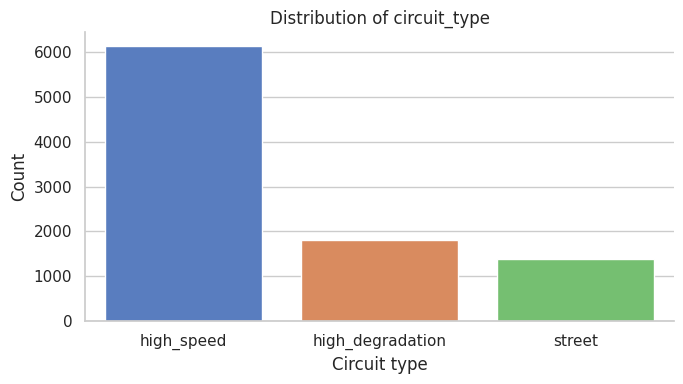

circuit_type
high_speed          6138
high_degradation    1800
street              1380
Name: count, dtype: int64


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = features['circuit_type'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=ax)
ax.set(xlabel='Circuit type', ylabel='Count',
       title='Distribution of circuit_type')
sns.despine()
plt.tight_layout()
plt.show()
print(features['circuit_type'].value_counts())

---
## Validation

In [10]:
REQUIRED_FEATURES = [
    'stop_lap_pct', 'gap_to_car_ahead', 'is_undercut_attempt',
    'compound_hardness', 'team_avg_stop_time', 'prior_stops', 'circuit_type'
]

for feat in REQUIRED_FEATURES:
    assert feat in features.columns, f"Missing feature: {feat}"
    nulls = features[feat].isnull().sum()
    assert nulls == 0, f"{feat} has {nulls} nulls"

assert 'team_avg_stop_time' in features.columns, "team_avg_stop_time missing"

if 'position_gained' in features.columns:
    assert features['position_gained'].isnull().sum() == 0
    assert set(features['position_gained'].dropna().unique()).issubset({0, 1})

print("All assertions passed.")
print(f"\nFinal feature matrix: {features.shape[0]:,} rows × {features.shape[1]} columns")
features.head()

All assertions passed.

Final feature matrix: 9,318 rows × 11 columns


,season,round,driver_id,stop_lap_pct,gap_to_car_ahead,is_undercut_attempt,compound_hardness,team_avg_stop_time,prior_stops,circuit_type,position_gained
0,2011,1,webber,0.189655,0.0,0,1,23.4260,0,street,0
1,2011,1,alonso,0.206897,0.0,0,1,23.2510,0,street,0
2,2011,1,massa,0.224138,0.0,0,1,23.5465,0,street,0
3,2011,1,barrichello,0.224138,0.0,0,1,23.6430,0,street,0
4,2011,1,vettel,0.241379,0.0,0,1,23.0145,0,street,0


---
## Save feature matrix

In [11]:
out_path = DATA / 'features.parquet'
features.to_parquet(out_path, index=False)
print(f"Saved: {out_path}")
print(f"  {features.shape[0]:,} rows × {features.shape[1]} columns")

Saved: /home/melvin/f1-pit-stop-strategy/data/features.parquet
  9,318 rows × 11 columns
